In [290]:
import yaml
from pathlib import Path
import os
from swiss_roll import RUNS_DIR, DATA_DIR, CONF_DIR, PROJECT_ROOT
import pandas as pd
from swiss_roll.scheduling import Schedular
import matplotlib.pyplot as plt
from swiss_roll.guidance import run_once, evaluate_model, get_dataloaders

import torch
import logging 
import matplotlib.pyplot as plt
import numpy as np 
from swiss_roll.utils import load_swissroll, load_model, save_model 
from swiss_roll.config import load_config, Config, TrainValMetrics, load_hyperoptconfig, save_config, HyperOptConfig
from swiss_roll.guidance import GuidanceModel  


In [354]:
def plot_surface(guidance_model: GuidanceModel, title: str, text: str = None):
    device='cpu'
    guidance_model.eval().cpu()
    X, Y, Xval, Yval = load_swissroll()
    X = X[:, [0, 2]]
    Y = Y[:, 0]
    Xval = Xval[:, [0, 2]]
    Yval = Yval[:, 0]


    T = 0
    expose_time = True 
    if expose_time: 
        tens = torch.zeros(size=(X.size()[0], 1))
        X_inp = torch.hstack([X, torch.fill(tens, T)])
        preds, _ = guidance_model(X_inp)
    else: 
        preds, _ = guidance_model(X)
    pred_means = preds[:, :1]
    pred_logvar = preds[:, 1:]
    pred_means = pred_means.to(device).detach().numpy()
    pred_logvar = pred_logvar.to(device).detach().numpy()

    n = 300
    x1_lin = x2_lin = np.linspace(-2.5, 2.5, n)
    XX, YY = np.meshgrid(x1_lin, x2_lin)
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
    with torch.no_grad():
        inp = torch.from_numpy(grid).float().to(device)
        if expose_time:
            tens = torch.zeros(size=(inp.size()[0], 1))
            inp = torch.hstack([inp, torch.fill(tens, T)])
        pred, _ = guidance_model(inp)
    mu = pred[:, :1]
    logvar = pred[:, 1:]
    ZZ = np.round(logvar.cpu().numpy().reshape(XX.shape), 2)
    ZZ_mu = np.round(mu.cpu().numpy().reshape(XX.shape), 2)

    fig, ax = plt.subplots(1, 2, figsize=(16,6))
    cf = ax[1].contourf(XX, YY, ZZ, levels=20, cmap='Purples')
    cf2 = ax[0].contourf(XX, YY, ZZ_mu, levels=20, cmap='coolwarm')
    fig.colorbar(cf, ax=ax[1], label='Predicted Log-Variance') 
    fig.colorbar(cf2, ax=ax[0], label='Predicted Mean')

    idx = torch.randperm(len(X))[: 10_000]
    ax[1].scatter(X[idx, 0], X[idx, 1], c=pred_logvar[idx], alpha=0.1, edgecolors='black', cmap='Purples') 
    ax[0].scatter(X[idx, 0], X[idx, 1], c=pred_means[idx], alpha=1, edgecolors='black', cmap='coolwarm')

    ax[1].set_title('Predicted Log-Variance')
    ax[1].set_xlabel('X_1')
    ax[1].set_ylabel('X_2')
    
    ax[0].set_xlabel('X_1')
    ax[0].set_ylabel('X_2')
    ax[0].set_title('Predicted Means')
    
    if isinstance(text, str): 
        fig.text(
        0.5,               # x-position in figure coordinates (0 = left, 1 = right)
        0.01,              # y-position (0 = bottom, 1 = top) – ≈1 % above bottom edge
        text,
        ha="center", va="bottom",
        fontsize=10, style="italic"
    )

    fig.suptitle(title) 
    plt.tight_layout()
    plt.close()
    return fig 

In [345]:
guidance_runs_path = RUNS_DIR / 'guidance_models_2'

print('Guidance run path exists:', guidance_runs_path.exists())

metrics_filename = 'eval_metrics.yaml'

Guidance run path exists: True


In [346]:
training_metrics_list = []
validation_metrics_list = []
successful_runs = []
failed_runs = []  
for root, dirs, _ in guidance_runs_path.walk():
    for dir in dirs:  
        metrics_path = root / dir / metrics_filename
        run_id =  int(dir.split("_")[-1])
        
        try:
            with open(metrics_path, 'r') as f:
                metrics = yaml.load(f, yaml.FullLoader)
        except FileNotFoundError:
            failed_runs.append(run_id)
            continue 

        successful_runs.append(run_id)
        metrics['training_metrics']['run_id'] = int(run_id)
        metrics['validation_metrics']['run_id'] = int(run_id)
        training_metrics_list.append(metrics['training_metrics'])
        validation_metrics_list.append(metrics['validation_metrics'])
print("Successful Runs:", len(successful_runs), "Failed Runs:", len(failed_runs))
training_metrics_dataframe = pd.DataFrame.from_records(training_metrics_list)
validation_metrics_dataframe = pd.DataFrame.from_records(validation_metrics_list)

Successful Runs: 378 Failed Runs: 72


In [347]:
guidance_confs_path = CONF_DIR / 'guidance_conf'

print('Guidance run path exists:', guidance_runs_path.exists())

conf_list = []
failed_conf_list = []  
for root, _, files in guidance_confs_path.walk():
    for file in files: 
        conf_path = root / file
        with open(conf_path, 'r') as f:
            conf = yaml.load(f, yaml.FullLoader)
       
        run_id =  int(file.split('.')[0]) 
        conf['run_id'] = run_id
       
        if run_id in successful_runs:
            conf_list.append(conf)
        else: 
            failed_conf_list.append(conf)

conf_dataframe = pd.DataFrame.from_records(conf_list)
failed_conf_dataframe = pd.DataFrame.from_records(failed_conf_list)

Guidance run path exists: True


In [348]:
def setup_conf(cfg: HyperOptConfig, row: pd.Series) -> HyperOptConfig:
        cfg.cfg.opt.l2_lambda = float(row['params_l2_lambda'])
        cfg.cfg.opt.lr = float(row['params_lr'])
        if cfg.cfg.run.reg_type == 'cgd':
            cfg.cfg.cgd.sigma_t = float(row['params_sigma_t'])
            cfg.cfg.cgd.tau_t = float(row['params_tau_t'])
        return cfg 

In [349]:
from optuna.visualization import plot_pareto_front
import numpy as np 

logging.basicConfig(filename='./exploration.log')
logger = logging.getLogger('__main__')
device = 'cpu'
dataloader, high_dataloader = get_dataloaders(128)
retrain = False
index = 1 

# Return paths of optuna csvs
if index == 0:
    bayesoptconfs = CONF_DIR / 'bayesopt_conf'
    bayesoptdir = RUNS_DIR / 'bayesopt'
    figuredir = DATA_DIR / 'figures' / 'bayesopt'
if index == 1:    
    bayesoptconfs = CONF_DIR / 'bayesopt_mse'
    bayesoptdir = RUNS_DIR / 'bayesopt_mse'
    figuredir = DATA_DIR / 'figures' / 'bayesopt_mse'
if index == 2:    
    bayesoptconfs = CONF_DIR / 'bayesopt_mse'
    bayesoptdir = RUNS_DIR / 'bayesopt_mse'
    figuredir = DATA_DIR / 'figures' / 'bayesopt_l2geq10'

run_results = {} 
for root, dirs, paths in bayesoptconfs.walk():
    for path in paths:
        cfg = load_hyperoptconfig(root / path)
        if cfg.cfg.run.update_embeds and cfg.cfg.run.reg_type in ['mse', 'None']:
            continue 
        run_id = cfg.cfg.run.run_id
        df = pd.read_csv(bayesoptdir / f'trials_{run_id}.csv')
        run_results[run_id] = {} 
        run_results[run_id]['cfg'] = cfg 
        run_results[run_id]['csv'] = df 

counter = 0
for key, value in run_results.items():
    cfg = value['cfg']
    df = value['csv']
    
    run_id = cfg.cfg.run.run_id
    reg_type = cfg.cfg.run.reg_type
    embeds = cfg.cfg.run.update_embeds
    reg_scalar = cfg.cfg.cgd.reg_scale_by
    pareto_front = cfg.pareto 
    title = f'Reg: {reg_type}, GM embeds: {embeds}, RegScale: {reg_scalar}'

    if pareto_front:
        df = df.rename(columns={"values_0": "val_nll", "values_1": "train_nll"})
        value['csv'] = df 
        # 2) find non-dominated points
        #    a point i is dominated if there's some j with both val_nll_j <= val_nll_i
        #    and train_nll_j <= train_nll_i, with at least one strict
        is_dominated = np.zeros(len(df), dtype=bool)
        for i, (v_i, t_i) in enumerate(df[["val_nll","train_nll"]].values):
            # check if any other point j dominates i
            dominated = ((df["val_nll"] <= v_i) &
                         (df["train_nll"] <= t_i) &
                         ((df["val_nll"] < v_i) | (df["train_nll"] < t_i)))
            # if any True (besides itself), it's dominated
            is_dominated[i] = dominated.any()

        pareto_df = df[~is_dominated]

        # 3) plot
        plt.figure(figsize=(6,6))
        plt.scatter(df["val_nll"], df["train_nll"], alpha=0.3, label="all trials")
        plt.scatter(pareto_df["val_nll"], pareto_df["train_nll"],
                    color="red", label="Pareto front")
        plt.xlabel("Validation NLL")
        plt.ylabel("Training NLL")
        plt.xlim(-2, 20)
        plt.ylim(-2, 20)
        plt.title(title)
        plt.savefig(figuredir / f'pareto_{run_id}.png')
        plt.close()
        pareto_df = pareto_df.sort_values('val_nll')
        run_results[run_id]['pareto_best'] = {}
        run_results[run_id]['csv'] = pareto_df
        try:
            if index == 2:
                local_cfg = setup_conf(cfg, pareto_df[pareto_df['params_l2_lambda'] > 10].iloc[0])
            else:
                local_cfg = setup_conf(cfg, pareto_df.iloc[0])
        except: 
            continue

        if (figuredir / f'model_{key}.pth').exists() and not retrain:
            guidance_model = load_model(GuidanceModel, {'input_dim':3}, figuredir / f'model_{key}.pth')
            validation_metrics = evaluate_model(guidance_model, high_dataloader, local_cfg.cfg, device) 
            training_metrics = evaluate_model(guidance_model, dataloader, local_cfg.cfg, device) 
        else: 
            training_metrics, validation_metrics, guidance_model = run_once(local_cfg.cfg, logger)
        
        metrics = TrainValMetrics(train=training_metrics, val=validation_metrics)
        run_results[run_id]['pareto_best'] = {} 
        run_results[run_id]['pareto_best']['metrics'] = metrics 
        run_results[run_id]['pareto_best']['model'] = guidance_model
        run_results[run_id]['pareto_best']['cfg'] = local_cfg

        print(f'{counter + 1} of {int(len(run_results))}')
    
    else:

        df = df.rename(columns={"value": "supervised_loss"})
        plt.figure(figsize=(6, 6))
        plt.scatter(df['number'], df['supervised_loss'], alpha=0.3, label="all trials")
        plt.xlabel("Trial ID")
        plt.ylabel("Supervised Loss")
        plt.title(title)
        plt.savefig(figuredir / f'loss_{run_id}')
        plt.close()

        # Extract parameter for best run
        
        df = df.sort_values('supervised_loss')
        value['csv'] = df
        try:
            if index == 2:
                local_cfg = setup_conf(cfg, df[df['params_l2_lambda'] > 10].iloc[0])
            else:
                local_cfg = setup_conf(cfg, df.iloc[0])
        except IndexError: 
            continue 
        # Retrain best model
        
        if (figuredir / f'model_{key}.pth').exists() and not retrain:
            guidance_model = load_model(GuidanceModel, {'input_dim':3}, figuredir / f'model_{key}.pth')
            validation_metrics = evaluate_model(guidance_model, high_dataloader, local_cfg.cfg, device) 
            training_metrics = evaluate_model(guidance_model, dataloader, local_cfg.cfg, device) 
        else: 
            training_metrics, validation_metrics, guidance_model = run_once(local_cfg.cfg, logger)
        
        metrics = TrainValMetrics(train=training_metrics, val=validation_metrics)
        run_results[run_id]['best'] = {} 
        run_results[run_id]['best']['metrics'] = metrics 
        run_results[run_id]['best']['model'] = guidance_model
        run_results[run_id]['best']['cfg'] = local_cfg
        
        print(f'{counter + 1} of {int(len(run_results))}') 
        
    counter+=1 

1 of 16
2 of 16
3 of 16
4 of 16
5 of 16
6 of 16
7 of 16
8 of 16
9 of 16
10 of 16
11 of 16
12 of 16
13 of 16
14 of 16
15 of 16
16 of 16


In [350]:
for key, value in run_results.items():
    if 'best' in value.keys():
        model = value['best']['model']
    elif 'pareto_best' in value.keys():
        model = value['pareto_best']['model']
    
    save_model(model, figuredir / f'model_{key}.pth')

In [355]:
for key, value in run_results.items():
    run_id = key

    if 'best' in value.keys():
        print(key, 'single')
        cfg = value['best']['cfg']
    elif 'pareto_best' in value.keys(): 
        print(key, 'pareto')
        cfg = value['pareto_best']['cfg']

    df = value['csv']
    try:
        if index == 2:
            best_run = df[df['params_l2_lambda'] > 10].iloc[0]
            best_run['params_l2_lambda']
        else:
            best_run = df.iloc[0]
    except: 
        continue
    trial = df['number']
    
    run_id = cfg.cfg.run.run_id
    reg_type = cfg.cfg.run.reg_type
    embeds = cfg.cfg.run.update_embeds
    reg_scalar = cfg.cfg.cgd.reg_scale_by
    pareto_front = cfg.pareto 
    text = f'Reg: {reg_type}, GM embeds: {embeds}, RegScale: {reg_scalar}'


    cfg.cfg.opt.l2_lambda = float(best_run['params_l2_lambda'])
    cfg.cfg.opt.lr = float(best_run['params_lr'])
    title = f"LR: {cfg.cfg.opt.lr:.2g}, L2 Lambda: {cfg.cfg.opt.l2_lambda:.2g}"
    
    if cfg.cfg.run.reg_type == 'cgd':
        cfg.cfg.cgd.sigma_t = float(best_run['params_sigma_t'])
        cfg.cfg.cgd.tau_t = float(best_run['params_tau_t'])
        title += f", Sigma: {cfg.cfg.cgd.sigma_t:.2g}, Tau: {cfg.cfg.cgd.tau_t:.2g}"
        
    if 'best' in value.keys():
        title += ", Supervised Loss"
        guidance_model = value['best']['model']

        fig = plot_surface(guidance_model, title, text)
        fig.savefig(figuredir / f'nonparetosurface_{run_id}.png')
   
    if 'pareto_best' in value.keys():
        title += ", Pareto Opt"
        guidance_model = value['pareto_best']['model']

        fig = plot_surface(guidance_model, title, text) 
        fig.savefig(figuredir / f'paretosurface_{run_id}.png')

11 pareto
07 single
01 single
02 pareto
10 pareto
15 single
05 single
13 single
08 pareto
06 pareto
09 single
14 pareto
03 pareto
04 single
00 pareto
12 single


In [361]:
df

,number,val_nll,train_nll,datetime_start,datetime_complete,duration,params_l2_lambda,params_lr,params_sigma_t,params_tau_t,state
26,26,-0.776502,44.039261,2025-07-02 11:59:36.079154,2025-07-02 12:02:19.121002,0 days 00:02:43.041848,4.378585,0.002647,18.766049,42.191294,COMPLETE
46,46,-0.746957,25.842512,2025-07-02 13:04:28.406525,2025-07-02 13:08:07.512224,0 days 00:03:39.105699,267.912240,0.004167,663.675665,13754.048400,COMPLETE
18,18,-0.684657,24.608257,2025-07-02 11:37:57.094121,2025-07-02 11:39:52.629146,0 days 00:01:55.535025,6.273402,0.003391,0.366056,10.087700,COMPLETE
20,20,-0.671176,20.903021,2025-07-02 11:41:35.883444,2025-07-02 11:43:02.995665,0 days 00:01:27.112221,31.157388,0.003121,4895.772202,0.000022,COMPLETE
22,22,-0.654888,18.579472,2025-07-02 11:44:19.996595,2025-07-02 11:49:18.562605,0 days 00:04:58.566010,68.134727,0.002329,1921.308652,0.001093,COMPLETE
33,33,-0.647657,17.995171,2025-07-02 12:21:56.431368,2025-07-02 12:26:31.184044,0 days 00:04:34.752676,2.499097,0.003544,0.002468,42.061479,COMPLETE
54,54,-0.540283,12.728605,2025-07-02 13:48:09.917515,2025-07-02 13:52:05.574037,0 days 00:03:55.656522,602.331759,0.001000,9.527957,12097.915827,COMPLETE
29,29,-0.184154,10.836198,2025-07-02 12:14:20.728874,2025-07-02 12:16:13.131858,0 days 00:01:52.402984,17.431519,0.001000,473.141120,0.013095,COMPLETE
17,17,1.079860,2.341203,2025-07-02 11:36:20.137522,2025-07-02 11:37:57.093949,0 days 00:01:36.956427,0.040417,0.001000,0.000108,0.003430,COMPLETE
1,1,1.255545,2.199768,2025-07-02 11:11:05.070926,2025-07-02 11:12:24.041751,0 days 00:01:18.970825,0.000292,0.007348,0.000363,0.000363,COMPLETE


In [440]:
# Regularisation Type # Top 3 Models by NLL validation set # Top 3 models by NLL Train Set # Top 3 Models by Loss Value

run_archive = {}
def select_best(value):
    return value.get('pareto_best') or value.get('best')

run_archive = {
    key: {
        'train_nll': best['metrics'].train.nll,
        'train_mse': best['metrics'].train.mse,
        'train_loss': float(best['metrics'].train.loss),
        'val_nll': best['metrics'].val.nll,
        'val_mse': best['metrics'].val.mse,
        'val_loss': float(best['metrics'].val.loss),
        
        'reg_scale_by': "".join(best['cfg'].cfg.cgd.reg_scale_by.split("_")[0]).capitalize(),
        'reg_type': best['cfg'].cfg.run.reg_type.upper(),
        'pareto': best['cfg'].pareto,
        'update_embeds': best['cfg'].cfg.run.update_embeds
    }
    for key, value in run_results.items()
    if (best := select_best(value)) is not None
}

df = pd.DataFrame.from_dict(run_archive, orient='index')

In [441]:

df

,train_nll,train_mse,train_loss,val_nll,val_mse,val_loss,reg_scale_by,reg_type,pareto,update_embeds
11,-0.622363,0.004970,-0.622125,19.876251,3.726878,19.877131,Dataset,CGD,True,False
07,1.290393,0.743652,1.294541,1.899492,1.958306,1.903638,Ctx,NONE,False,False
01,-0.371162,0.011221,-0.370867,23.306568,3.783751,23.306862,Ctx,MSE,False,False
02,-0.633106,0.006653,-0.633091,44.585991,4.269189,44.586006,Ctx,CGD,True,True
10,-0.631203,0.010867,-0.631203,47.873454,4.138469,47.873451,Dataset,CGD,True,True
15,1.223172,0.652192,1.226925,2.279476,2.475980,2.293423,Dataset,NONE,False,False
05,1.292502,0.749091,1.294516,1.891171,1.936979,1.893185,Ctx,CGD,False,False
13,-0.529888,0.006996,-0.529886,2.078243,2.370977,2.078249,Dataset,CGD,False,False
08,-0.629892,0.007636,-0.629356,44.286253,3.807263,44.288250,Dataset,MSE,True,False
06,-0.634255,0.006902,-0.634239,48.026821,4.312181,48.026825,Ctx,NONE,True,False


In [431]:
dropped = df.drop(columns=['val_loss', 'train_loss']).sort_index()

In [435]:
with open(figuredir.parent / "run_results_table.tex", "w") as f:
    dropped.round(3).to_latex(
        buf=f,
        index=False,
        index_names=False,
        column_format="rrrrrrllcc",
        header=[
            "Train NLL", "Train MSE",
            "Val NLL", "Val MSE",
            "Scale", "Reg.", "Pareto", "Update Embeds"
        ],
        caption=(
            "Summary of training and validation performance across runs. "
            "Models vary by regularisation type (reg\\_type), scaling method (reg\\_scale\\_by), "
            "and whether context embeddings are updated."
        ),
        label="tab:run_results",
        escape=False  # Needed to allow underscores in LaTeX
    )


In [439]:
import pandas as pd
import numpy as np

def export_iclr_latex_table(df, filename="run_results_table.tex"):
    # Drop unwanted columns
    df = df.drop(columns=[col for col in df.columns if 'loss' in col.lower()])

    # Identify numeric columns to format
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Find best (lowest) values per numeric column
    best_values = df[numeric_cols].min()

    # Format values in scientific notation and bold the best
    def format_val(val, col):
        formatted = f"{val:.2e}"
        if np.isclose(val, best_values[col]):
            return f"\\textbf{{{formatted}}}"
        return formatted

    formatted_df = df.copy()
    for col in numeric_cols:
        formatted_df[col] = df[col].apply(lambda v: format_val(v, col))

    # Build LaTeX table
    latex = formatted_df.to_latex(
        index=False,
        escape=False,
        column_format='@{}l' + 'r' * (len(df.columns) - 1) + '@{}',
        header=[
            "Train NLL", "Train MSE",
            "Val NLL", "Val MSE",
            "Scale", "Reg.", "Pareto", "Update Embeds"
        ],
        bold_rows=False,
        caption=(
            "Validation performance across configurations. "
            "We vary regularisation type (\\texttt{reg\\_type}), scaling method (\\texttt{reg\\_scale\\_by}), "
            "and whether context embeddings are updated. Bolded values indicate the best (lowest) in each column."
        ),
        label="tab:run_results"
    )

    # Add \small and booktabs-style table wrapper
    latex = (
        "\\begin{table}[h]\n"
        "\\centering\n"
        "\\small\n"
        + latex +
        "\\end{table}\n"
    )

    # Write to file
    with open(filename, "w") as f:
        f.write(latex)

    print(f"LaTeX table exported to {filename}")

export_iclr_latex_table(dropped, figuredir.parent / "run_results_table.tex")

LaTeX table exported to /home/michaeldodds/Projects/manchester/ethics_ai/context-guided-diffusion/swiss_roll/data/figures/run_results_table.tex


In [ ]:
val_conf = validation_metrics_dataframe.merge(conf_dataframe, how='inner', on='run_id')
val_conf = val_conf.sort_values(by='mse')
best_run = val_conf.iloc[0]['run_id']

train_conf = training_metrics_dataframe.merge(conf_dataframe, how='inner', on='run_id')
train_conf = train_conf.sort_values(by='mse')
best_run = training_metrics_dataframe.iloc[0]['run_id'].astype(int)

In [244]:
device = 'cpu'
X, Y, Xval, Yval = load_swissroll()
X = X[:, [0, 2]]
Y = Y[:, 0]
Xval = Xval[:, [0, 2]]
Yval = Yval[:, 0]

mse_list = []
mse_val = [] 
run_id = [] 
run_id = 98
model_path = guidance_runs_path / f"run_{run_id:04d}" / "guidance_model.pth"

conf_path = PROJECT_ROOT / "src/swiss_roll/example.yaml"
model_path = PROJECT_ROOT / "src/swiss_roll/example/guidance_model.pth"

# cfg = load_config(conf_path)
model_config = {"input_dim": 3}
with torch.no_grad():

    model = run_results['04']['best']['model']
    # model = load_model(GuidanceModel, model_config, model_path)
    model.eval().to('cpu')

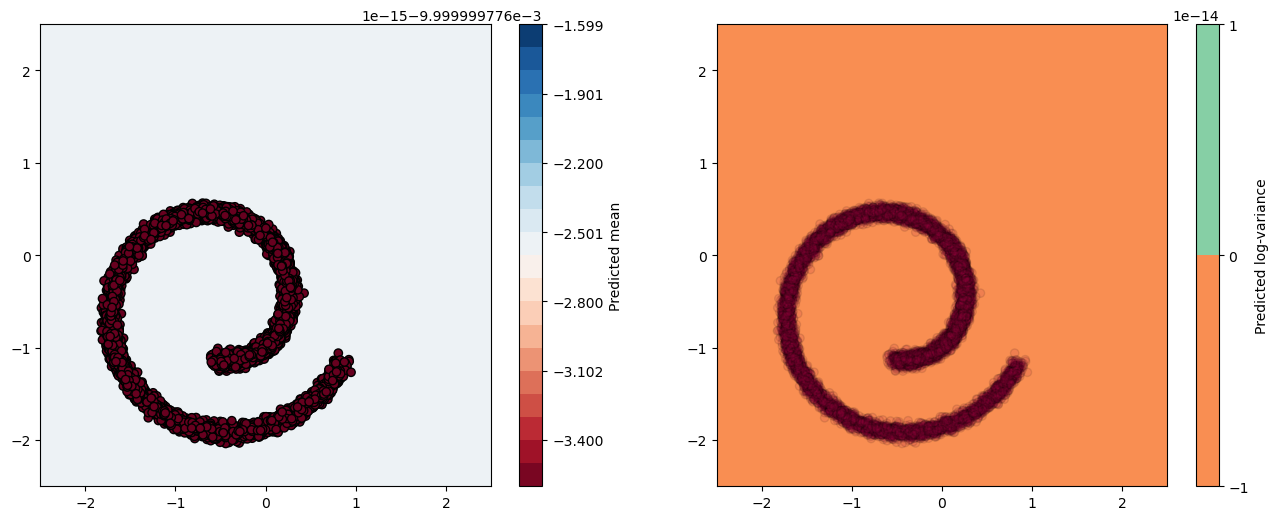

In [274]:
T = 0
expose_time = True 
if expose_time: 
    tens = torch.zeros(size=(X.size()[0], 1))
    X_inp = torch.hstack([X, torch.fill(tens, T)])
    preds, _ = model(X_inp)
else: 
    preds, _ = model(X)
pred_means = preds[:, :1]
pred_logvar = preds[:, 1:]
pred_means = pred_means.to(device).detach().numpy()
pred_logvar = pred_logvar.to(device).detach().numpy()

n = 300
x1_lin = x2_lin = np.linspace(-2.5, 2.5, n)
XX, YY = np.meshgrid(x1_lin, x2_lin)
grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
with torch.no_grad():
    inp = torch.from_numpy(grid).float().to(device)
    if expose_time:
        tens = torch.zeros(size=(inp.size()[0], 1))
        inp = torch.hstack([inp, torch.fill(tens, T)])
    pred, _ = model(inp)
mu = pred[:, :1]
logvar = pred[:, 1:]
ZZ = np.round(logvar.cpu().numpy().reshape(XX.shape), 2)
ZZ_mu = np.round(mu.cpu().numpy().reshape(XX.shape), 2)

fig, ax = plt.subplots(1, 2, figsize=(16,6))
cf = ax[1].contourf(XX, YY, ZZ, levels=20, cmap='Spectral')
cf2 = ax[0].contourf(XX, YY, ZZ_mu, levels=20, cmap='RdBu')
fig.colorbar(cf, ax=ax[1], label='Predicted log-variance') 
fig.colorbar(cf2, ax=ax[0], label='Predicted mean')

idx = torch.randperm(len(X))[: 10_000]
ax[1].scatter(X[idx, 0], X[idx, 1], c=pred_logvar[idx], alpha=0.1, edgecolors='black', cmap='Spectral')
ax[0].scatter(X[idx, 0], X[idx, 1], c=pred_means[idx], alpha=1, edgecolors='black', cmap='RdBu')

In [ ]:
from torch.distributions import Normal
from swiss_roll.guidance import get_dataloaders, evaluate_model
lowdataloader, highdataloader = get_dataloaders(128)

evaluate_model(model, highdataloader, cfg, device='cpu')

Metrics(nll=1.8928739683936444, mse=1.946340572466757, loss=tensor(1.8929), l2=tensor(4.4411e-08, grad_fn=<DivBackward0>), cov=1.0)